# 

In [1]:
#IMPORTANT LIBS 
import yfinance as yp
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as mt 

In [2]:
AIR_ASIA=yp.download("5099.KL",period="6mo")[["Close","Volume"]].dropna() 
print(AIR_ASIA.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price        Close    Volume
Ticker     5099.KL   5099.KL
Date                        
2024-12-06   1.000   9637600
2024-12-09   0.995  10205300
2024-12-10   0.990  19654100
2024-12-11   1.010  16255600
2024-12-12   0.995   7178800


In [3]:
print(AIR_ASIA.index)

DatetimeIndex(['2024-12-06', '2024-12-09', '2024-12-10', '2024-12-11',
               '2024-12-12', '2024-12-13', '2024-12-16', '2024-12-17',
               '2024-12-18', '2024-12-19',
               ...
               '2025-05-23', '2025-05-26', '2025-05-27', '2025-05-28',
               '2025-05-29', '2025-05-30', '2025-06-03', '2025-06-04',
               '2025-06-05', '2025-06-06'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


In [4]:
#Collapse Multi-index format to obtain date-time index form 

AIR_ASIA.columns=['_'.join(col) for col in AIR_ASIA.columns]

In [5]:
print(AIR_ASIA.head())

            Close_5099.KL  Volume_5099.KL
Date                                     
2024-12-06          1.000         9637600
2024-12-09          0.995        10205300
2024-12-10          0.990        19654100
2024-12-11          1.010        16255600
2024-12-12          0.995         7178800


In [6]:
AIR_ASIA["Returns"]=AIR_ASIA["Close_5099.KL"].pct_change()
print(AIR_ASIA["Returns"])

Date
2024-12-06         NaN
2024-12-09   -0.005000
2024-12-10   -0.005025
2024-12-11    0.020202
2024-12-12   -0.014851
                ...   
2025-05-30   -0.022988
2025-06-03    0.035294
2025-06-04    0.005682
2025-06-05   -0.011299
2025-06-06   -0.005714
Name: Returns, Length: 120, dtype: float64


**VISUALIZE THE RETURNS** 

Axes(0.125,0.2;0.775x0.68)


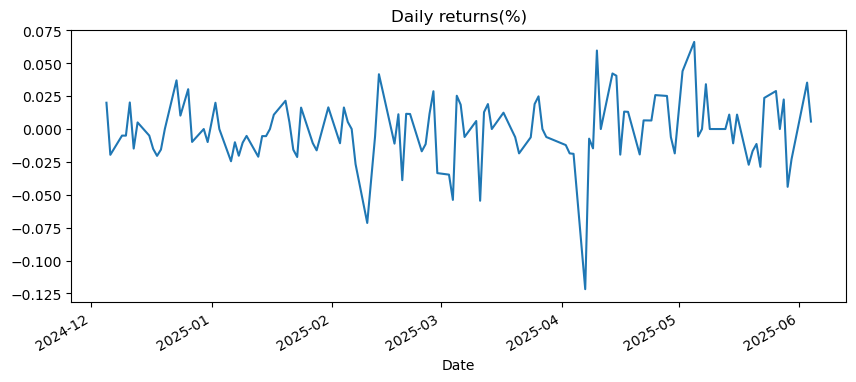

In [8]:
print(AIR_ASIA["Returns"].plot(title="Daily returns(%)", figsize=(10,4)))

**Grouping Your Returns**

In [7]:
def classify_return(r):
    if r > 0.05:
        return "Trading Days with High Returns"
    elif 0.01<=r<0.05:
        return "Trading Days with Moderate Returns"
    else:
        return"Trading days with Low Returns"

In [8]:
AIR_ASIA["Returns_Category"]=AIR_ASIA["Returns"].apply(classify_return)
AIR_ASIA["Returns_Category"].value_counts()

Returns_Category
Trading days with Low Returns         80
Trading Days with Moderate Returns    38
Trading Days with High Returns         2
Name: count, dtype: int64

**INTERPRETATION** 

 80 days of trading registered low returns [Low returns from December 2024 to April].
Probabily because of post festive season financial recovery accompanied with serious commitments such as school tuition, debt and going back to work. Therefore less passengers resulting low stock price as buying pressure is low.

38 days of trading resulted in moderate output 
These are caused by early investors who have a good understanding of the cyclical nature of travel and tourism business. These are probabily risk averse and risk neutral clients with high expectation of bullish momentum as the year progresses towards festive season.

Only 2 days rewarded high returns and seen in the 2nd quota of 2025 
Sentiments could have been kindled by positive news on Tourism and Aviation industries. Probably there was an event that was expected to boost business. For example, the Manchester United vs ASEAN All Stars match or the ASEAN SUMMIT.

In General 

>Dec to Feb returns were low

>Feb to April returns were variable [no solid conviction]

>Early April registered the lowest return but was immediately reversed showing strong convidence in the stock's intrinsic value.

>Mid April to June, returns averaged moderate to high. Investors want to buy now before it comes too expensive towards festive season.

>Highest returns on Mid April and early June. Look at popular events around this time.


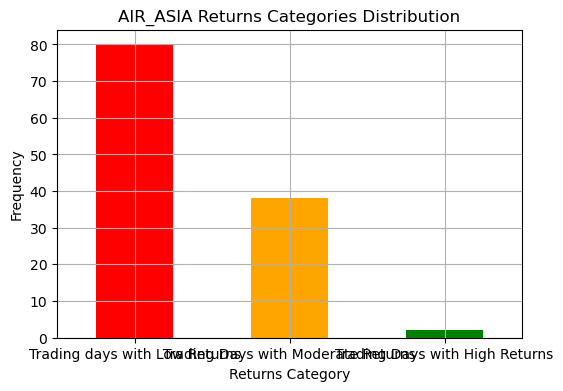

In [9]:
#Visualize Distribution of Returns 

AIR_ASIA["Returns_Category"].value_counts().plot(kind="bar",color=["red","orange","green"],figsize=(6,4))
mt.title("AIR_ASIA Returns Categories Distribution")
mt.xlabel("Returns Category")
mt.ylabel("Frequency")
mt.grid(True)
mt.xticks(rotation=0)
mt.show()                                                 

In [12]:
AIR_ASIA["Volatility"]=AIR_ASIA["Returns"].rolling(14).std()
print(AIR_ASIA["Volatility"])

Date
2024-12-04         NaN
2024-12-05         NaN
2024-12-06         NaN
2024-12-09         NaN
2024-12-10         NaN
                ...   
2025-05-28    0.020197
2025-05-29    0.021558
2025-05-30    0.022179
2025-06-03    0.024618
2025-06-04    0.024441
Name: Volatility, Length: 120, dtype: float64


In [13]:
print(AIR_ASIA["Volatility"])

Date
2024-12-04         NaN
2024-12-05         NaN
2024-12-06         NaN
2024-12-09         NaN
2024-12-10         NaN
                ...   
2025-05-28    0.020197
2025-05-29    0.021558
2025-05-30    0.022179
2025-06-03    0.024618
2025-06-04    0.024441
Name: Volatility, Length: 120, dtype: float64


**VISUALIZE VOLATILITY [Stability]**

Axes(0.125,0.2;0.775x0.68)


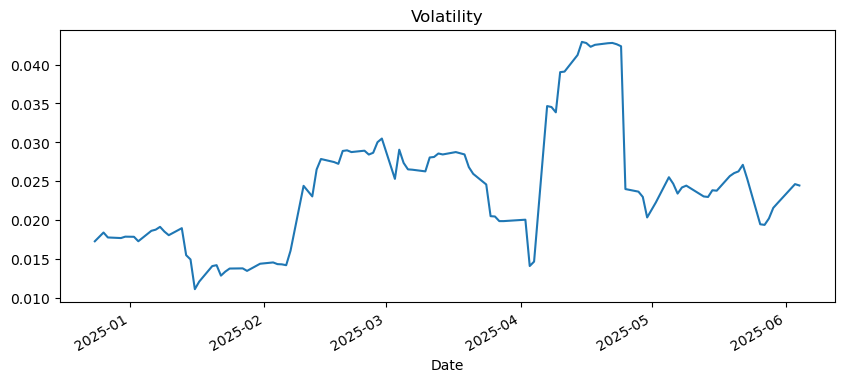

In [14]:
print(AIR_ASIA["Volatility"].plot(title="Volatility", figsize=(10,4)))  #how frequently was the price changing 

**ANALYSIS OF VOLATILITY**

> Flat in the last month of 2025. Price had low frequency of changes making it attractive for risk averse clients. Is this typical of mid-cap firms?


> Sharp decline mid January may result from Post festive season recovery.


> Went flat till February then spike upwards with slight changes until mid March.


> What were investor senstiments in periods of frequent price changes. Investors had no confidence in price from February till April.

Axes(0.125,0.2;0.775x0.68)


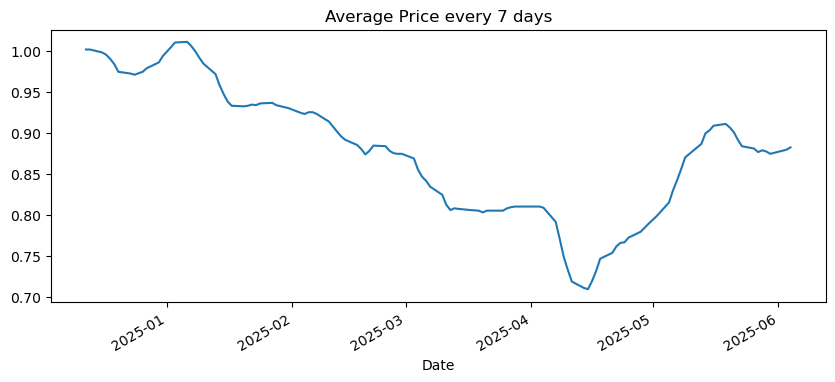

In [15]:
#Moving average: avg price over the given time period 
AIR_ASIA["SMA_7"]=AIR_ASIA["Close_5099.KL"].rolling(window=7).mean()
print(AIR_ASIA["SMA_7"].plot(title="Average Price every 7 days", figsize=(10,4)))

In [16]:
AIR_ASIA["SMA_14"]=AIR_ASIA["Close_5099.KL"].rolling(window=14).mean()
AIR_ASIA["SMA_21"]=AIR_ASIA["Close_5099.KL"].rolling(window=21).mean()

Axes(0.125,0.2;0.775x0.68)


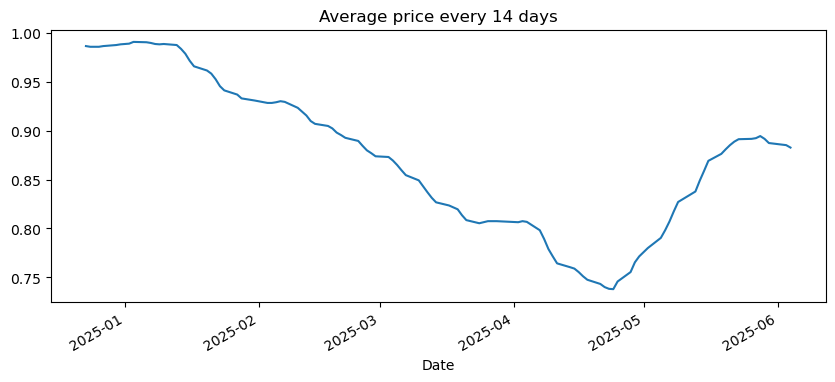

In [17]:
print(AIR_ASIA["SMA_14"].plot(title="Average price every 14 days", figsize=(10,4)))

Axes(0.125,0.2;0.775x0.68)


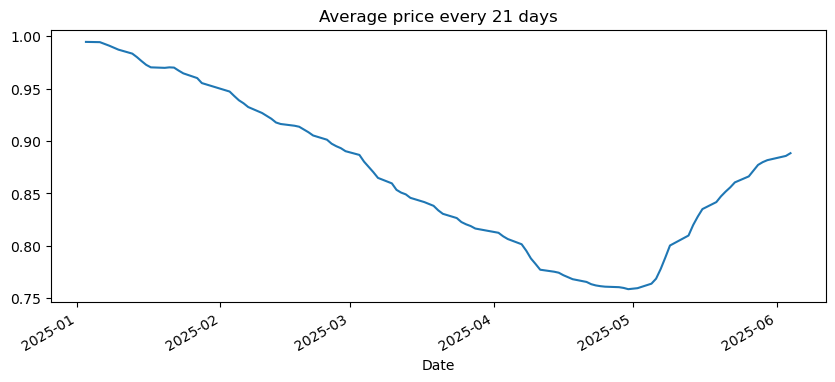

In [18]:
print(AIR_ASIA["SMA_21"].plot(title="Average price every 21 days" ,figsize=(10,4)))

**COMBINNING ALL THE CONCEPTS FOR A FULL VIEW** 

In [53]:
#INTRODUCE SUPPORT AND RESISTANCE LEVELS 
AIR_ASIA["Resistance"] =AIR_ASIA["Close_5099.KL"].rolling(21).max()#highest closing price 
AIR_ASIA["Support"] =AIR_ASIA["Close_5099.KL"].rolling(21).min() #lowest closing price


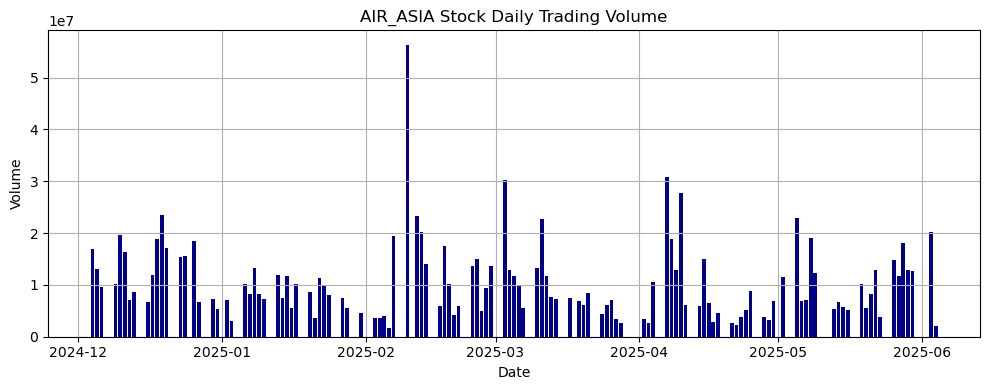

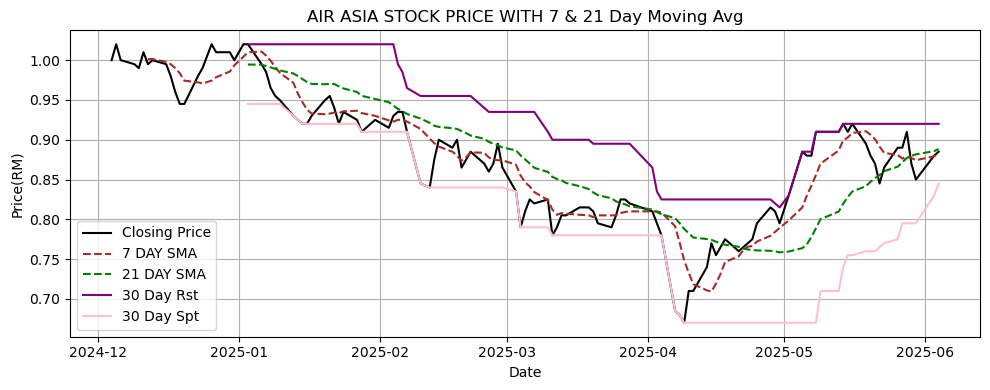

In [54]:
#BAR CHART: DAILY TRADING VOLUME 
mt.figure(figsize=(10,4))
mt.bar(AIR_ASIA.index,AIR_ASIA["Volume_5099.KL"],color="darkblue")
mt.title("AIR_ASIA Stock Daily Trading Volume")
mt.xlabel("Date")
mt.ylabel("Volume")
mt.grid(True)
mt.tight_layout()
mt.show()

#OVERLAY CHART: PRICE MOVEMENT WITH BOTH 7 AND 21-DAY MOVING AVERAGES
#We are using 7 and 21 day overlay so that signals can be atrributed to a longer time frame.This is so that we fully consider the seasonality of AIR ASIA that comes from cycles in travel demand, fuel prices and economic conditions.
#This makes it easier to identify price reversals 
#We will also fix in support and resistance levels to see if there's any specific price for which reversal occurs
mt.figure(figsize=(10,4))
mt.plot(AIR_ASIA["Close_5099.KL"], label="Closing Price",color="black", linewidth=1.5)
mt.plot(AIR_ASIA["SMA_7"],label="7 DAY SMA",color="brown",linestyle="--")
mt.plot(AIR_ASIA["SMA_21"],label="21 DAY SMA",color="green",linestyle="--")
mt.plot(AIR_ASIA["Resistance"],label="30 Day Rst",color="purple",linestyle="solid")
mt.plot(AIR_ASIA["Support"],label="30 Day Spt",color="pink",linestyle="solid")

mt.title("AIR ASIA STOCK PRICE WITH 7 & 21 Day Moving Avg")
mt.xlabel("Date")
mt.ylabel("Price(RM)")
mt.grid(True)
mt.legend()
mt.tight_layout()
mt.show()


>PRICE NEVER BROKE SUPPORT AND RESISTANCE LEVELS. Strong price consolidation. IT is possible to have more confidence in technical analysis


>Resistance is the highest price reached by stock/instrument in a defined timeframe. Price going beyond resistance indicates high likelihood of reversal into bearish movement. Meaning there are only a few investors willing to buy at such price so selling becomes high.


>Support is the lowest price a stock/instrument being traded has reached in the given back test period. If price goes below it, reversal is likely to occur. This is because this is the lowest price sellers are willing to sell at, so will want dispose the asset as fast possible. This results in an increased number of buys which results in bullish momemntum as price rises rapidly.


>Best for retail traders who rely on technical analysis over short trading periods.

**LETS ANALYSE THE CHARTS**

**KEY PRINCIPLES**

>Moving averages compare average prices over specified time periods. 
-Shorter time frame avg > Longer time frame avg then that means prices are higher in recent times than in the past. The stock is gaining value
-Shows that people are buying more and more of the stock
-Trading Physcology: You want to is surf this wave and buy aswell [ if you can't beat them join them]...suitable for both risk averse and risk taking clients.

-Shorter time frame avg < Longer time frame avg then that means prices in recent times are much lower than in the past.
-Shows that value of stock is dropping. Possible contraction of business
-Short selling is now occuring
-Trading Physcology: You want to sell the stock before it completely loses value >>>especially for risk averse clients


>In terms of AIR ASIA whats actually happening?
-Strong Bearish movement in  the first 4 months of 2925. Why?
-Strong Bullish movement from early April to mid May. Why?
-Mid May till today we are in consolidation. Price could reverse or continue bullish

TO BE CERTAIN WE NEED TO ASSESS NEWS ON AIR_ASIA on past occuramnces
Questions to ASK:
-did positive news bring up increase in stock price: i.e holiday promotions etc 
-How did investors react to end of 2024 report. Did it cause this sharp bearish movement. If not, what did? 

In the End 
-Risk Averse (unwilling) : what strategy shud they take from today into the future 
-Risk taking : .....
-Risk neutral:......

**FURTHER REFINEMENT USING TECHNICAL ANALYSIS**

RELATIVE STRENGTH INDEX(RSI):
>detects over-bought or over-sold conditions 


>Overbought means that price has been increasing way beyond intrinsic value suggesting that price reversal/correction may occur. Usually happens when noise surrounds the trade i.e anouncement of new partnership or positive year end financial report.
-Overbought is identied when RSI value > 70

>Oversold means that price has decreased way below intrinsic value suggesting that price reversal into bullish trend is likely. Usually occur after negative news e.g The April-June 2025 USA Tariffs
-Identified when RSI <30

>30<= RSI <=70 suggests a period of strong price conviction. What ever events occuring have strong and justified correlation with price.

In [34]:
!pip install pandas_ta


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218925 sha256=81f3901bdd0224476bda272797e5fc09e567a5c4c7b166853b976aad1f5bfb07
  Stored in directory: c:\users\malcolm muchenje\appdata\local\pip\cache\wheels\fd\ed\18\2a12fd1b7906c63efca6accb351929f2c7f6bbc674e1c0ba5d
Successfully built pandas_ta


**RELATIVE STRENGTH INDEX (RSI)**

In [10]:
import pandas_ta as ta  #pandas_ta is a technical analysis library 
AIR_ASIA["RSI"]=ta.rsi(AIR_ASIA["Close_5099.KL"],length=14)
print(AIR_ASIA[["Close_5099.KL","RSI"]].tail())

            Close_5099.KL        RSI
Date                                
2025-05-30          0.850  47.658715
2025-06-03          0.880  53.754075
2025-06-04          0.885  54.700918
2025-06-05          0.875  52.390597
2025-06-06          0.870  51.225614


In [11]:
def RSI_level(x):
    if x>70:
        return "Days where stock was OVERBOUGHT so Price was likely to fall if momentum was weak"
    elif 30<=x<=70:
        return "Days with normal trades where Whatever trend present was maintained" 
    else:
        return "Days where stock was OVERSOLD so Price likely to rise despite weak buying pressure"


In [12]:
AIR_ASIA["RSI categories"]=AIR_ASIA["RSI"].apply(RSI_level)
AIR_ASIA["RSI categories"].value_counts()

RSI categories
Days with normal trades where Whatever trend present was maintained                   94
Days where stock was OVERSOLD so Price likely to rise despite weak buying pressure    21
Days where stock was OVERBOUGHT so Price was likely to fall if momentum was weak       5
Name: count, dtype: int64

In [40]:
OVERBOUGHT=70
OVERSOLD=30

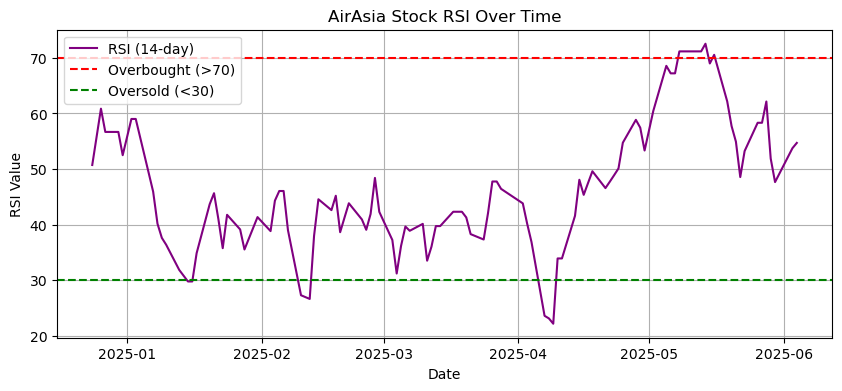

In [42]:
mt.figure(figsize=(10, 4))
mt.plot(data.index, AIR_ASIA["RSI"], label="RSI (14-day)", color="purple")
mt.axhline(OVERBOUGHT, linestyle="--", color="red", label="Overbought (>70)")
mt.axhline(OVERSOLD, linestyle="--", color="green", label="Oversold (<30)")

mt.title("AirAsia Stock RSI Over Time")
mt.xlabel("Date")
mt.ylabel("RSI Value")
mt.legend()
mt.grid(True)
mt.show()


ANALYSIS

>Occurence of overbought and oversold conditions is not significant so we can confirm this to be a stable stock!



>Compliments the Support and Resistance shown 
